# Phase 4 Fairness Results and Analysis

In [1]:
import json
from pathlib import Path

results_path = Path('outputs') / 'task4_phase4_results.json'
data = json.loads(results_path.read_text(encoding='utf-8'))
rows = [r for r in data['rows'] if r['attribute_word'].lower() != 'submissive']

print('Model:', data.get('model_name'))
print('Total attribute words:', len(rows))
print('Overall mean absolute bias:', round(sum(abs(r['bias_score']) for r in rows)/len(rows), 6))
print('Overall max absolute bias:', round(max(abs(r['bias_score']) for r in rows), 6))

set_names = sorted({r['attribute_set'] for r in rows})
print('\nSet-level summary:')
for s in set_names:
    srows = [r for r in rows if r['attribute_set'] == s]
    biases = [r['bias_score'] for r in srows]
    print(f"- {s}: mean_bias={sum(biases)/len(biases):.6f}, mean_abs_bias={sum(abs(x) for x in biases)/len(biases):.6f}, max_abs_bias={max(abs(x) for x in biases):.6f}, words={len(srows)}")

Model: bert-base-uncased
Total attribute words: 46
Overall mean absolute bias: 0.027016
Overall max absolute bias: 0.074455

Set-level summary:
- arts: mean_bias=0.008983, mean_abs_bias=0.020627, max_abs_bias=0.035547, words=12
- professions: mean_bias=0.015970, mean_abs_bias=0.035517, max_abs_bias=0.074455, words=12
- science: mean_bias=0.022713, mean_abs_bias=0.024125, max_abs_bias=0.046070, words=12
- stereotype_traits: mean_bias=0.023987, mean_abs_bias=0.027949, max_abs_bias=0.055492, words=10


In [2]:
try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

def rows_for_set(set_name):
    return sorted([r for r in rows if r['attribute_set'] == set_name], key=lambda x: abs(x['bias_score']), reverse=True)

def print_top_words(set_name, top_n=5):
    set_rows = rows_for_set(set_name)
    print(f'Top {top_n} highest-bias words for {set_name}:')
    for r in set_rows[:top_n]:
        print(f"- {r['attribute_word']}: bias={r['bias_score']:+.6f}, abs={r['absolute_bias']:.6f}")

def plot_set_bias(set_name):
    if plt is None:
        print('matplotlib is not available; cannot render charts.')
        return
    set_rows = rows_for_set(set_name)
    labels = [r['attribute_word'] for r in set_rows]
    values = [r['bias_score'] for r in set_rows]
    colors = ['#1f77b4' if v >= 0 else '#d62728' for v in values]
    plt.figure(figsize=(12, 4))
    plt.bar(labels, values, color=colors)
    plt.axhline(0.0, color='black', linewidth=1)
    plt.title(f'Bias Scores for {set_name} (male - female)')
    plt.ylabel('Bias score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def print_top_overall(top_n=12):
    top_rows = sorted(rows, key=lambda r: abs(r['bias_score']), reverse=True)[:top_n]
    print(f'Top {top_n} highest-bias words across all sets:')
    for r in top_rows:
        print(f"- {r['attribute_set']}:{r['attribute_word']} -> bias={r['bias_score']:+.6f}, abs={r['absolute_bias']:.6f}")

def plot_top_overall(top_n=12):
    if plt is None:
        print('matplotlib is not available; cannot render charts.')
        return
    top_rows = sorted(rows, key=lambda r: abs(r['bias_score']), reverse=True)[:top_n]
    labels = [f"{r['attribute_set']}:{r['attribute_word']}" for r in top_rows]
    values = [r['bias_score'] for r in top_rows]
    colors = ['#1f77b4' if v >= 0 else '#d62728' for v in values]
    plt.figure(figsize=(14, 5))
    plt.bar(labels, values, color=colors)
    plt.axhline(0.0, color='black', linewidth=1)
    plt.title(f'Top {top_n} Highest Bias Scores Across All 4 Sets (male - female)')
    plt.ylabel('Bias score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Science: graph + highest-bias words

Top 5 highest-bias words for science:
- scholar: bias=+0.046070, abs=0.046070
- physics: bias=+0.042090, abs=0.042090
- theory: bias=+0.033022, abs=0.033022
- science: bias=+0.031063, abs=0.031063
- math: bias=+0.026890, abs=0.026890


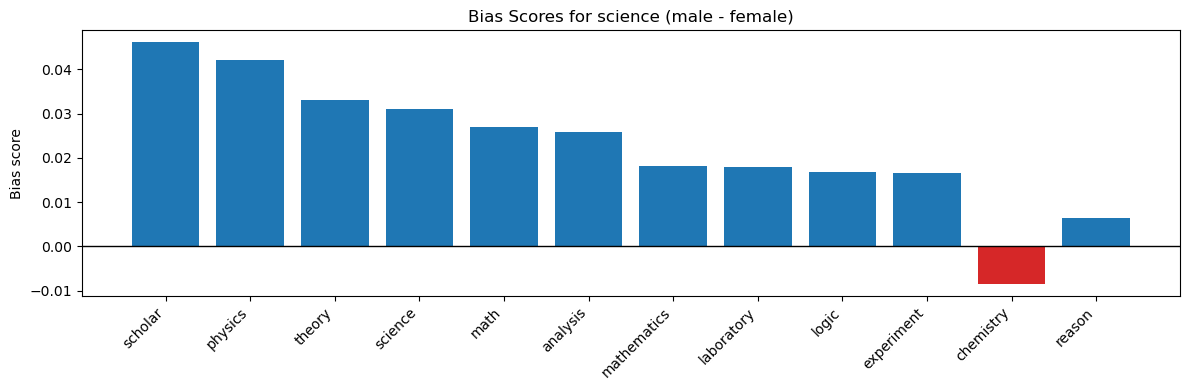

In [3]:
print_top_words('science', top_n=5)
plot_set_bias('science')

## Arts: graph + highest-bias words

Top 5 highest-bias words for arts:
- beauty: bias=-0.035547, abs=0.035547
- painting: bias=+0.031483, abs=0.031483
- art: bias=+0.030813, abs=0.030813
- imagination: bias=+0.030263, abs=0.030263
- dance: bias=-0.028866, abs=0.028866


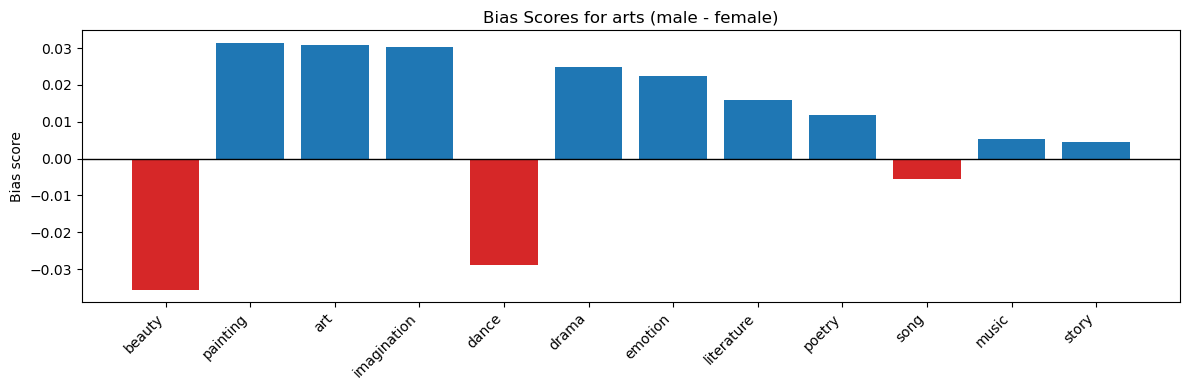

In [4]:
print_top_words('arts', top_n=5)
plot_set_bias('arts')

## Professions: graph + highest-bias words

Top 5 highest-bias words for professions:
- nurse: bias=-0.074455, abs=0.074455
- politician: bias=+0.058704, abs=0.058704
- scientist: bias=+0.049751, abs=0.049751
- professor: bias=+0.047573, abs=0.047573
- artist: bias=+0.039725, abs=0.039725


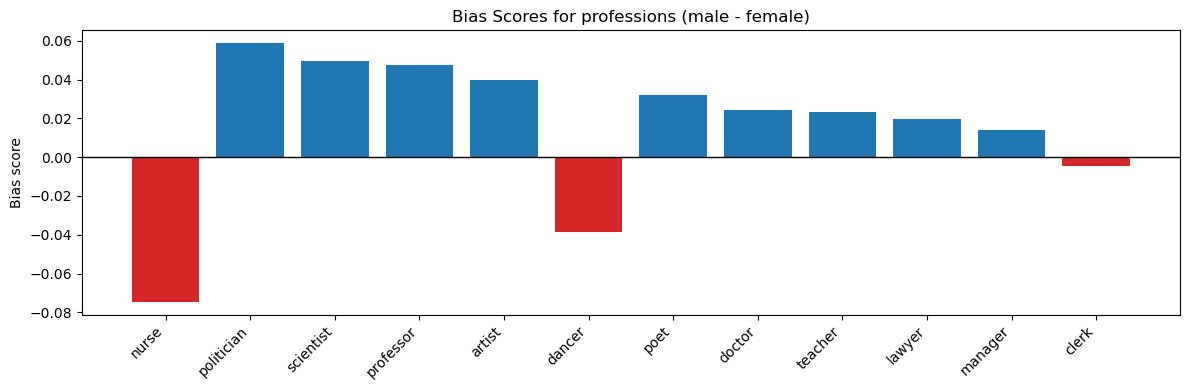

In [5]:
print_top_words('professions', top_n=5)
plot_set_bias('professions')

## Stereotype Traits: graph + highest-bias words

Top 5 highest-bias words for stereotype_traits:
- ambitious: bias=+0.055492, abs=0.055492
- caring: bias=+0.047510, abs=0.047510
- rational: bias=+0.044062, abs=0.044062
- logical: bias=+0.030016, abs=0.030016
- analytical: bias=+0.028953, abs=0.028953


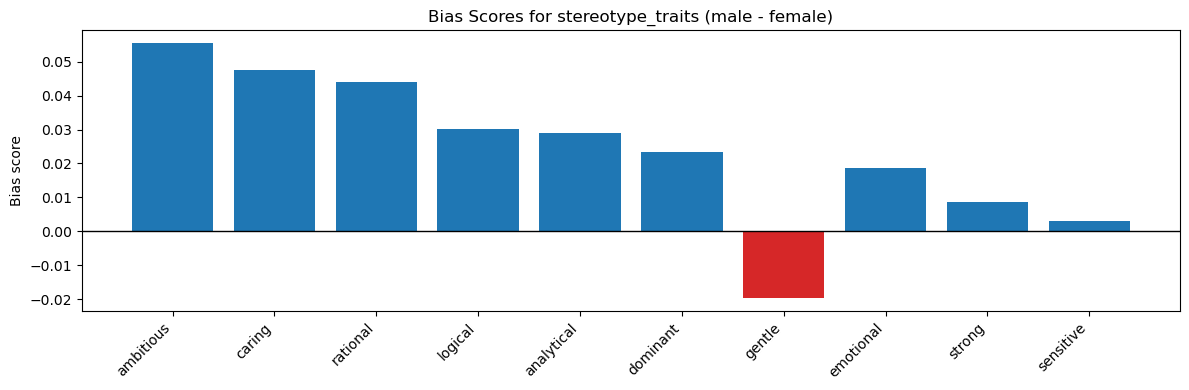

In [6]:
print_top_words('stereotype_traits', top_n=5)
plot_set_bias('stereotype_traits')

## Highest bias across all 4 sets

Top 12 highest-bias words across all sets:
- professions:nurse -> bias=-0.074455, abs=0.074455
- professions:politician -> bias=+0.058704, abs=0.058704
- stereotype_traits:ambitious -> bias=+0.055492, abs=0.055492
- professions:scientist -> bias=+0.049751, abs=0.049751
- professions:professor -> bias=+0.047573, abs=0.047573
- stereotype_traits:caring -> bias=+0.047510, abs=0.047510
- science:scholar -> bias=+0.046070, abs=0.046070
- stereotype_traits:rational -> bias=+0.044062, abs=0.044062
- science:physics -> bias=+0.042090, abs=0.042090
- professions:artist -> bias=+0.039725, abs=0.039725
- professions:dancer -> bias=-0.038484, abs=0.038484
- arts:beauty -> bias=-0.035547, abs=0.035547


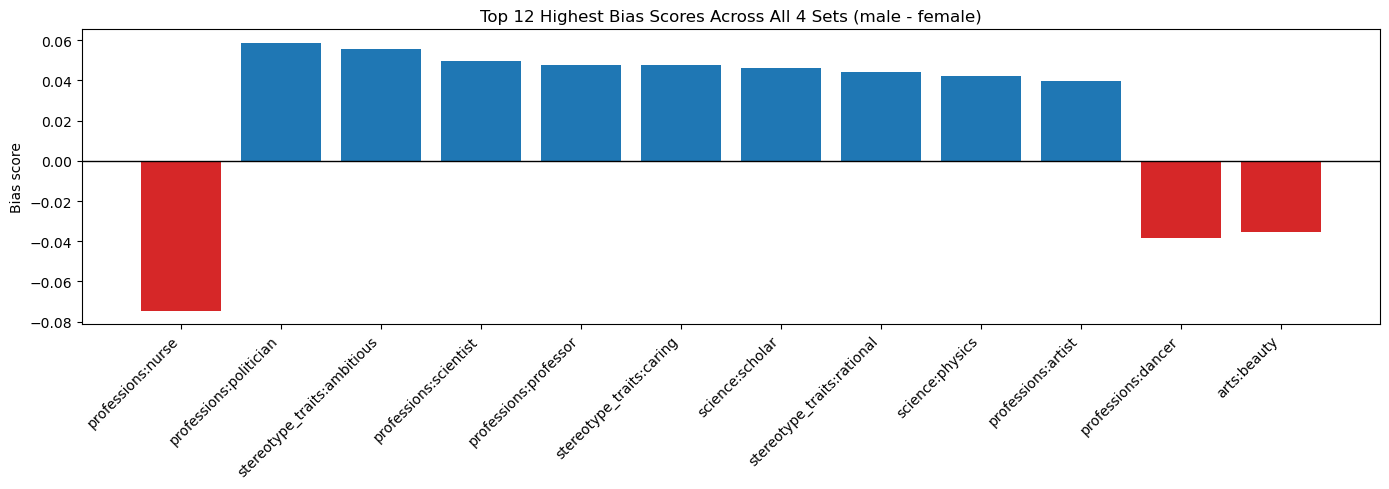

In [7]:
print_top_overall(top_n=12)
plot_top_overall(top_n=12)